# OpinIA — Inteligencia de reputación online para e-commerce español
## Práctica de PLN | Técnicas avanzadas en IA y Big Data | CEU San Pablo

**Autora:** María Luisa Ros Bolea

![texto del enlace](
  https://drive.google.com/uce?
  id=1OEh4A0XNw0xg3WCU2o8nNY-qoM51f5PG/
)


Este cuaderno desarrolla **OpinIA**, una prueba de concepto (PoC) de procesamiento de lenguaje natural orientada al análisis automatizado de reseñas de productos en español. La idea de negocio es sencilla pero potente: ayudar a marcas y retailers a entender qué dicen sus clientes, detectar tendencias negativas antes de que escalen y priorizar mejoras de producto basándose en datos reales, no en intuiciones.

Para construir la PoC hemos necesitado tres cosas: una idea con sentido de negocio, un dataset real y varios modelos de PLN capaces de extraer valor del texto. Lo que viene a continuación es el resultado de combinar las tres.

## Índice del cuaderno

1. **Configuración del entorno y paleta visual**
2. **Carga y exploración del dataset**
3. **Preprocesamiento de texto (pipeline clásico)**
4. **Línea base clásica: BoW y TF-IDF con modelos de ML tradicionales**
5. **Análisis de sentimiento con Transformers (BERT multilingüe)**
6. **Fine-tuning de un modelo encoder para clasificación de sentimiento**
7. **Clasificación zero-shot para categorías de negocio**
8. **Extracción de entidades con NER**
9. **Modelado de temas (topic modeling) con LDA**
10. **Búsqueda semántica con embeddings y FAISS**
11. **Comparativa de modelos y dashboard de resultados**
12. **Conclusiones y visión de producto**

## **1. Configuración del entorno y paleta visual**

Lo primero es montar el entorno. Necesitamos bastantes librerías porque vamos a tocar desde lo más clásico (scikit-learn, NLTK) hasta lo más moderno (HuggingFace Transformers, FAISS, sentence-transformers). Todo lo instalamos de golpe para no tener que volver a reiniciar el runtime a mitad de análisis, que es una de esas cosas que te arruinan la tarde.

In [ ]:
%%time
import time
start_total = time.time()

# Instalaciones necesarias para Colab
!pip install -q transformers datasets accelerate sentencepiece
!pip install -q sentence-transformers faiss-cpu
!pip install -q nltk wordcloud gensim
!pip install -q evaluate scikit-learn

print("Todas las dependencias instaladas correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00
Todas las dependencias instaladas correctamente.
CPU times: user 9.15 s, sys: 1.27 s, total: 10.4 s
Wall time: 47.6 s


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings, os, re, time
warnings.filterwarnings('ignore')

# Paleta visual OpinIA: tonos azulados, pasteles y blanco
AZUL         = '#5B9BD5'
AZUL_OSCURO  = '#2E5F8A'
AZUL_CLARO   = '#A8D1F0'
LAVANDA      = '#B8A9D0'
ROSA_PASTEL  = '#F2B5D4'
MELOCOTON    = '#FFD4B8'
BLANCO       = '#FAFCFF'
GRIS         = '#7B8794'
PALETA = [AZUL_OSCURO, AZUL, LAVANDA, ROSA_PASTEL, MELOCOTON, GRIS]

sns.set_theme(style='whitegrid', font_scale=1.05)
sns.set_palette(PALETA)
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 120,
    'axes.facecolor': BLANCO,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print(f'Entorno configurado. {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print(f'Paleta OpinIA cargada: {PALETA}')

Entorno configurado. 2026-03-29 12:36
Paleta OpinIA cargada: ['#2E5F8A', '#5B9BD5', '#B8A9D0', '#F2B5D4', '#FFD4B8', '#7B8794']


## **2. Carga y exploración del dataset**

El dataset que hemos elegido es **Amazon Reviews Multi** de HuggingFace, que contiene reseñas reales de productos de Amazon en varios idiomas. Trabajamos exclusivamente con el subconjunto en español. Cada reseña incluye el texto completo y la puntuación de estrellas (1 a 5).

¿Por qué este dataset? Porque cumple los tres requisitos fundamentales de cualquier proyecto de PLN serio: es texto real (no sintético), tiene etiquetas fiables (las estrellas las puso el propio usuario) y tiene volumen suficiente para entrenar modelos. Con 210.000 reseñas en castellano, es uno de los corpus de opinión en español más grandes disponibles públicamente.

In [ ]:
from datasets import load_dataset
import time

t0 = time.time()
print("Descargando dataset Amazon Reviews Multi (subset español)...")

# Usamos la versión SetFit que está en formato parquet nativo
dataset = load_dataset("SetFit/amazon_reviews_multi_es")

print(f"Descarga completada en {time.time()-t0:.1f}s")
print(f"\nParticiones disponibles:")
for split_name, split_data in dataset.items():
    print(f"  {split_name}: {len(split_data):,} reseñas")

df_train = dataset['train'].to_pandas()
df_val   = dataset['validation'].to_pandas()
df_test  = dataset['test'].to_pandas()

# Renombramos columnas para coherencia en el notebook
for d in [df_train, df_val, df_test]:
    d.rename(columns={'text': 'review_body', 'label': 'stars', 'label_text': 'label_text'}, inplace=True)
    d['review_title'] = ''
    d['stars'] = d['stars'] + 1  # de 0-4 a 1-5

df = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f"\nDataset combinado: {len(df):,} reseñas x {len(df.columns)} columnas")
print(f"Columnas: {list(df.columns)}")

Descargando dataset Amazon Reviews Multi (subset español)...


README.md:   0%|          | 0.00/310 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/43.8M [00:00<?, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/200000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Descarga completada en 10.0s

Particiones disponibles:
  train: 200,000 reseñas
  validation: 5,000 reseñas
  test: 5,000 reseñas

Dataset combinado: 210,000 reseñas x 5 columnas
Columnas: ['id', 'review_body', 'stars', 'label_text', 'review_title']


In [ ]:
# Vista rápida de los datos
print("Primeras 5 reseñas:")
display(df[['review_body', 'stars']].head(5))

print(f"\nEstadísticas de estrellas:")
print(df['stars'].describe().round(2))

print(f"\nDistribución de estrellas:")
for star in sorted(df['stars'].unique()):
    n = (df['stars'] == star).sum()
    pct = n / len(df) * 100
    print(f"  {star} estrella{'s' if star > 1 else '':4s}: {n:>6,} ({pct:.1f}%)")

Primeras 5 reseñas:


,review_body,stars
0,Nada bueno se me fue ka pantalla en menos de 8...,1
1,"Horrible, nos tuvimos que comprar otro porque ...",1
2,Te obligan a comprar dos unidades y te llega s...,1
3,"No entro en descalificar al vendedor, solo pue...",1
4,Llega tarde y co la talla equivocada,1



Estadísticas de estrellas:
count    210000.00
mean          3.00
std           1.41
min           1.00
25%           2.00
50%           3.00
75%           4.00
max           5.00
Name: stars, dtype: float64

Distribución de estrellas:
  1 estrella    : 42,000 (20.0%)
  2 estrellas   : 42,000 (20.0%)
  3 estrellas   : 42,000 (20.0%)
  4 estrellas   : 42,000 (20.0%)
  5 estrellas   : 42,000 (20.0%)


### Creación de la variable objetivo: sentimiento

Las estrellas nos dan una granularidad de 1 a 5, pero para que la clasificación de sentimiento sea más limpia y tenga más sentido de negocio (a un inversor le interesa saber si la opinión es positiva, negativa o neutra, no si es un 3 o un 4), agrupamos en tres categorías:

- **Negativo**: 1-2 estrellas (el cliente no está contento)
- **Neutro**: 3 estrellas (ni frío ni calor)
- **Positivo**: 4-5 estrellas (cliente satisfecho)

Esta agrupación es estándar en la literatura de análisis de sentimiento y nos permite comparar nuestros modelos con benchmarks publicados.

In [ ]:
def mapear_sentimiento(stars):
    if stars <= 2:
        return 'negativo'
    elif stars == 3:
        return 'neutro'
    else:
        return 'positivo'

df['sentimiento'] = df['stars'].apply(mapear_sentimiento)
df['sentimiento_num'] = df['sentimiento'].map({'negativo': 0, 'neutro': 1, 'positivo': 2})

# Texto combinado (título + cuerpo)
df['texto_completo'] = df['review_title'].fillna('') + '. ' + df['review_body'].fillna('')
df['largo_texto'] = df['texto_completo'].str.len()

print("Variable de sentimiento creada:")
for sent in ['negativo', 'neutro', 'positivo']:
    n = (df['sentimiento'] == sent).sum()
    print(f"  {sent:10s}: {n:>6,} ({n/len(df)*100:.1f}%)")

print(f"\nLargo medio del texto: {df['largo_texto'].mean():.0f} caracteres")
print(f"Largo mediano: {df['largo_texto'].median():.0f} caracteres")

Variable de sentimiento creada:
  negativo  : 84,000 (40.0%)
  neutro    : 42,000 (20.0%)
  positivo  : 84,000 (40.0%)

Largo medio del texto: 153 caracteres
Largo mediano: 122 caracteres


### Visualización exploratoria

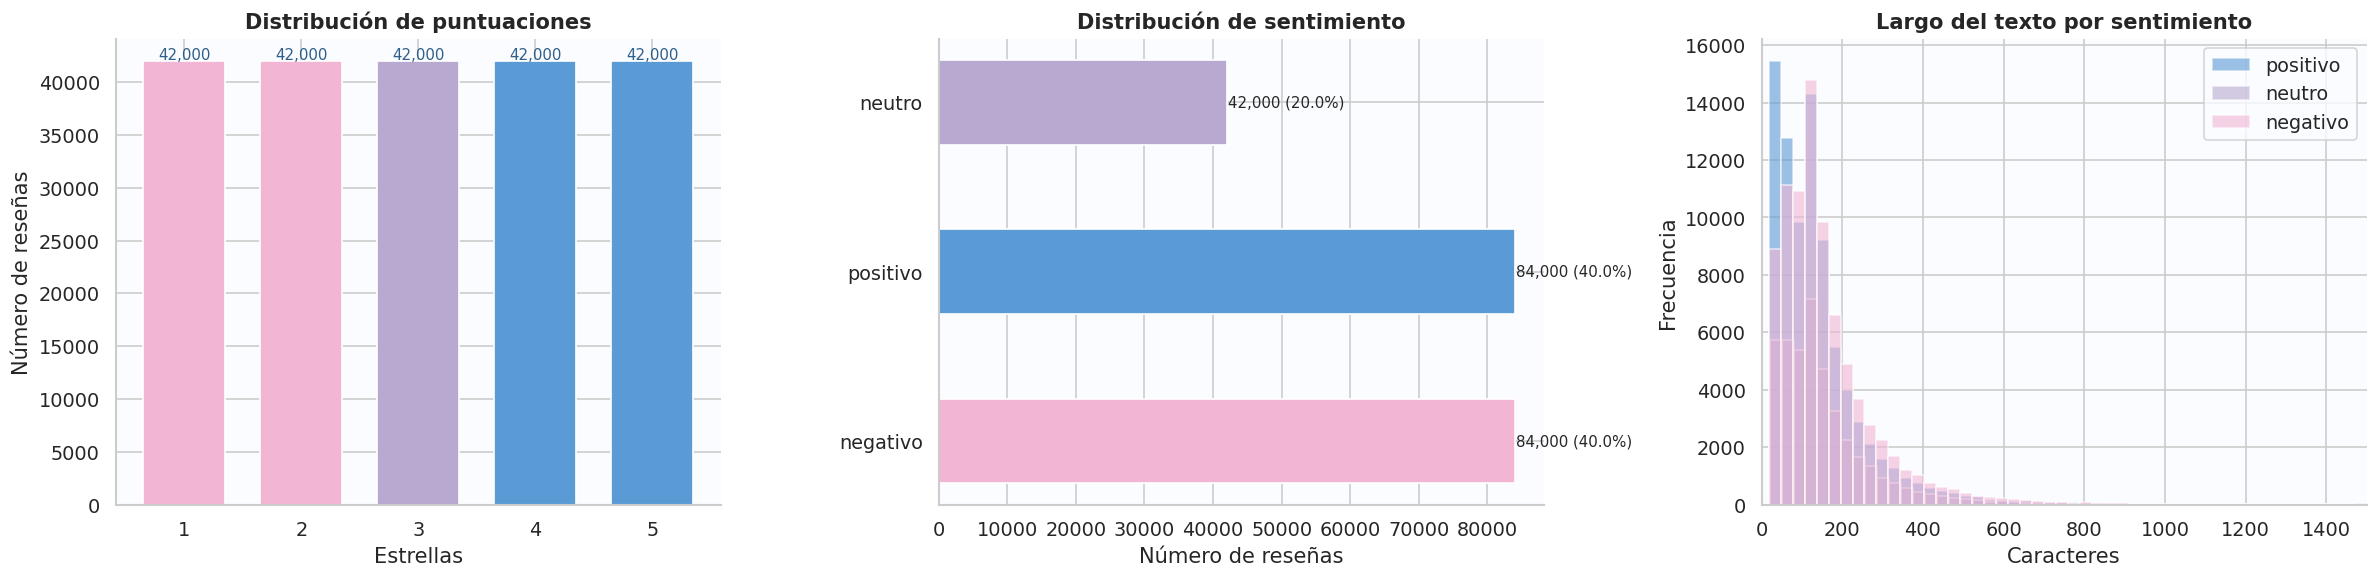

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Distribución de estrellas
star_counts = df['stars'].value_counts().sort_index()
colors_stars = [ROSA_PASTEL if s <= 2 else LAVANDA if s == 3 else AZUL for s in star_counts.index]
axes[0].bar(star_counts.index, star_counts.values, color=colors_stars, edgecolor='white', width=0.7)
axes[0].set_xlabel('Estrellas')
axes[0].set_ylabel('Número de reseñas')
axes[0].set_title('Distribución de puntuaciones', fontweight='bold')
for i, (x, y) in enumerate(zip(star_counts.index, star_counts.values)):
    axes[0].text(x, y + 200, f'{y:,}', ha='center', fontsize=9, color=AZUL_OSCURO)

# 2. Distribución de sentimiento
sent_counts = df['sentimiento'].value_counts()
colores_sent = {'positivo': AZUL, 'neutro': LAVANDA, 'negativo': ROSA_PASTEL}
axes[1].barh(sent_counts.index, sent_counts.values,
             color=[colores_sent[s] for s in sent_counts.index],
             edgecolor='white', height=0.5)
axes[1].set_xlabel('Número de reseñas')
axes[1].set_title('Distribución de sentimiento', fontweight='bold')
for i, (y, x) in enumerate(zip(sent_counts.index, sent_counts.values)):
    axes[1].text(x + 200, y, f'{x:,} ({x/len(df)*100:.1f}%)', va='center', fontsize=9)

# 3. Largo del texto por sentimiento
for sent, color in colores_sent.items():
    subset = df[df['sentimiento'] == sent]['largo_texto']
    axes[2].hist(subset.clip(upper=1500), bins=50, alpha=0.6, color=color, label=sent, edgecolor='white')
axes[2].set_xlabel('Caracteres')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Largo del texto por sentimiento', fontweight='bold')
axes[2].legend()
axes[2].set_xlim(0, 1500)

plt.tight_layout()
plt.show()

### Interpretación de la exploración

El primer gráfico muestra que el dataset está **perfectamente balanceado**: exactamente 42.000 reseñas por cada nivel de estrellas. Esto es una característica del dataset Amazon Reviews Multi, que fue curado para que cada clase tenga el mismo peso. Desde el punto de vista del modelado esto es una ventaja porque no necesitamos técnicas de rebalanceo (como oversampling o ponderación de clases) y las métricas de accuracy son directamente comparables.

Al agrupar en sentimiento, la distribución queda 40% negativo, 20% neutro y 40% positivo. El neutro tiene la mitad de muestras porque solo incluye las 3 estrellas, mientras que negativo agrupa 1 y 2, y positivo agrupa 4 y 5.

El tercer gráfico revela algo interesante: las reseñas negativas tienden a ser **ligeramente más largas** que las positivas. Esto es un patrón conocido en la literatura de opinión online: cuando un cliente está descontento, invierte más tiempo en explicar qué ha salido mal. Para los modelos de PLN esto es relevante porque significa que las reseñas negativas aportan más información textual por documento.

## **3. Preprocesamiento de texto (pipeline clásico)**

Antes de lanzar cualquier modelo, toca limpiar el texto. Este paso es el equivalente a lo que vimos en clase como el ***pipeline clásico de procesado de texto***: tomar el texto en bruto y transformarlo en algo que un algoritmo pueda digerir.

Aplicamos las operaciones estándar: convertir a minúsculas, eliminar URLs, números excesivos, caracteres especiales y stopwords. Para la tokenización usamos NLTK con soporte para español. No aplicamos stemming porque, como vimos en clase, tiende a ser demasiado agresivo con el castellano ("corriendo" → "corr" no es muy informativo). En su lugar, confiamos en que los modelos de transformers manejen la morfología internamente mediante su tokenizador subword (BPE o WordPiece).

In [ ]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords

stop_es = set(stopwords.words('spanish'))
stop_es.update(['producto', 'compré', 'comprar', 'amazon', 'vendedor', 'envío',
                'llegó', 'bien', 'mal', 'si', 'no', 'muy', 'más', 'menos'])

def limpiar_texto(texto):
    """Limpieza básica para modelos clásicos (BoW/TF-IDF)."""
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+', '', texto)
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    tokens = texto.split()
    tokens = [t for t in tokens if t not in stop_es and len(t) > 2]
    return ' '.join(tokens)

t0 = time.time()
df['texto_limpio'] = df['texto_completo'].apply(limpiar_texto)
print(f"Texto limpiado en {time.time()-t0:.1f}s")

# Ejemplo antes/después
idx = df[df['largo_texto'] > 100].sample(1, random_state=42).index[0]
print(f"\nEjemplo de limpieza:")
print(f"  ORIGINAL: {df.loc[idx, 'texto_completo'][:200]}...")
print(f"  LIMPIO:   {df.loc[idx, 'texto_limpio'][:200]}...")
print(f"\nTextos vacíos tras limpieza: {(df['texto_limpio'].str.len() == 0).sum()}")

Texto limpiado en 15.3s

Ejemplo de limpieza:
  ORIGINAL: . He comprado en teoría un set de 6 sartenes San Ignacio....y cuando me han llegado hay 3 San Ignacio y 3 bergner.... No estoy nada contenta. Puede que sean de la misma fábrica pero en la descripción ...
  LIMPIO:   comprado teoría set sartenes san ignacio llegado san ignacio bergner contenta puede misma fábrica descripción viene indicado marcas distintas...

Textos vacíos tras limpieza: 48


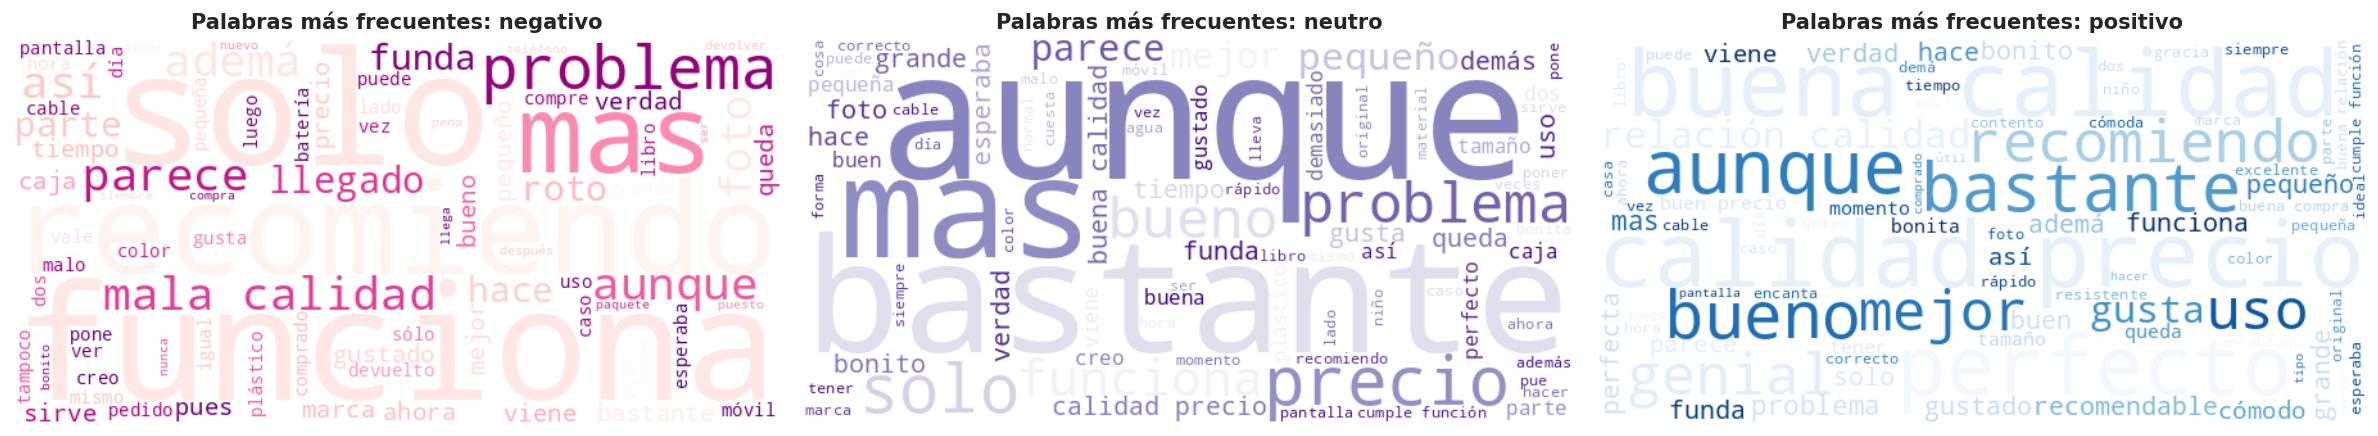

In [ ]:
# Nube de palabras por sentimiento
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, (sent, color) in enumerate(zip(['negativo', 'neutro', 'positivo'],
                                       [ROSA_PASTEL, LAVANDA, AZUL])):
    texto_todo = ' '.join(df[df['sentimiento'] == sent]['texto_limpio'].dropna())
    if len(texto_todo) > 0:
        wc = WordCloud(width=600, height=300, background_color='white',
                       colormap='RdPu' if sent == 'negativo' else 'Purples' if sent == 'neutro' else 'Blues',
                       max_words=80, random_state=42)
        wc.generate(texto_todo)
        axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Palabras más frecuentes: {sent}', fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Interpretación de las nubes de palabras

Las tres nubes revelan diferencias claras en el vocabulario de cada tipo de sentimiento:

- **Negativo** (izquierda): dominan palabras como "problema", "mala calidad", "llegado", "parece", "roto", "devolver". El vocabulario gira en torno a defectos del producto y decepciones con las expectativas.
- **Neutro** (centro): aparece una mezcla de palabras positivas y negativas como "aunque", "parece", "precio", "calidad", "problema". Esto confirma que las reseñas de 3 estrellas son las más ambiguas y, por tanto, las más difíciles de clasificar automáticamente.
- **Positivo** (derecha): destacan "bueno", "mejor", "funciona", "recomiendo", "bastante", "gusta". El vocabulario es más uniforme y se centra en satisfacción y funcionalidad.

Esta diferenciación léxica nos da confianza de que incluso los modelos más sencillos (BoW, TF-IDF) podrán distinguir entre sentimiento positivo y negativo, aunque el neutro seguirá siendo un reto.

## **4. Línea base clásica: BoW y TF-IDF con modelos de ML**

Antes de lanzar los transformers, necesitamos una línea base sólida con técnicas clásicas. Esto es fundamental por dos razones: primero, para demostrar que entendemos los fundamentos (BoW, TF-IDF, etc., que vimos extensamente en clase); segundo, porque si un transformer no supera a un TF-IDF + Logistic Regression por un margen significativo, quizá no merece la pena el coste computacional extra.

Usamos las dos representaciones clásicas del texto que estudiamos:
- ***Bag of Words (BoW)***: cuenta cuántas veces aparece cada palabra en cada documento, ignorando el orden. Como vimos en clase, esta representación pierde toda la semántica y el orden de las palabras, pero funciona sorprendentemente bien para clasificación.
- ***TF-IDF (Term Frequency - Inverse Document Frequency)***: pondera cada palabra según su frecuencia en el documento (TF) y su rareza en el corpus (IDF). Así da más peso a las palabras discriminantes y menos a las que aparecen en todas partes.

Sobre estos vectores entrenamos tres clasificadores: Logistic Regression (rápido y difícil de superar en texto), SVM lineal y Random Forest.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score
import time

X = df['texto_limpio'].values
y = df['sentimiento_num'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Distribución train: {np.bincount(y_train)}")
print(f"Distribución test:  {np.bincount(y_test)}")

Train: 168,000 | Test: 42,000
Distribución train: [67200 33600 67200]
Distribución test:  [16800  8400 16800]


In [ ]:
# Vectorización
t0 = time.time()

bow_vec = CountVectorizer(max_features=15000, ngram_range=(1,2))
X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow  = bow_vec.transform(X_test)

tfidf_vec = TfidfVectorizer(max_features=15000, ngram_range=(1,2), sublinear_tf=True)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

print(f"Vectorización completada en {time.time()-t0:.1f}s")
print(f"Vocabulario: {len(tfidf_vec.vocabulary_):,} tokens (unigramas + bigramas)")
print(f"Dimensión de la matriz: {X_train_tfidf.shape}")

Vectorización completada en 41.4s
Vocabulario: 15,000 tokens (unigramas + bigramas)
Dimensión de la matriz: (168000, 15000)


In [ ]:
# Entrenar modelos clásicos
resultados_clasicos = []

modelos = {
    'LogReg + BoW': (LogisticRegression(max_iter=1000, C=1.0, random_state=42), X_train_bow, X_test_bow),
    'LogReg + TF-IDF': (LogisticRegression(max_iter=1000, C=1.0, random_state=42), X_train_tfidf, X_test_tfidf),
    'SVM + TF-IDF': (LinearSVC(max_iter=2000, C=1.0, random_state=42), X_train_tfidf, X_test_tfidf),
    'RF + TF-IDF': (RandomForestClassifier(n_estimators=200, max_depth=50, random_state=42, n_jobs=-1), X_train_tfidf, X_test_tfidf),
}

for nombre, (modelo, X_tr, X_te) in modelos.items():
    t0 = time.time()
    modelo.fit(X_tr, y_train)
    y_pred = modelo.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    t_total = time.time() - t0

    resultados_clasicos.append({
        'modelo': nombre, 'accuracy': acc, 'f1_weighted': f1, 'tiempo_s': t_total
    })
    print(f"\n{'='*60}")
    print(f"{nombre} | Accuracy: {acc:.4f} | F1: {f1:.4f} | Tiempo: {t_total:.1f}s")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['negativo', 'neutro', 'positivo']))

df_clasicos = pd.DataFrame(resultados_clasicos)
print("\nResumen de modelos clásicos:")
display(df_clasicos.sort_values('f1_weighted', ascending=False))


LogReg + BoW | Accuracy: 0.6942 | F1: 0.6744 | Tiempo: 37.9s
              precision    recall  f1-score   support

    negativo       0.72      0.80      0.76     16800
      neutro       0.41      0.24      0.30      8400
    positivo       0.74      0.82      0.78     16800

    accuracy                           0.69     42000
   macro avg       0.62      0.62      0.61     42000
weighted avg       0.67      0.69      0.67     42000


LogReg + TF-IDF | Accuracy: 0.7057 | F1: 0.6808 | Tiempo: 32.9s
              precision    recall  f1-score   support

    negativo       0.72      0.83      0.77     16800
      neutro       0.44      0.22      0.29      8400
    positivo       0.75      0.83      0.79     16800

    accuracy                           0.71     42000
   macro avg       0.64      0.62      0.62     42000
weighted avg       0.68      0.71      0.68     42000


SVM + TF-IDF | Accuracy: 0.6979 | F1: 0.6706 | Tiempo: 19.9s
              precision    recall  f1-score   sup

,modelo,accuracy,f1_weighted,tiempo_s
1,LogReg + TF-IDF,0.705690,0.680769,32.858312
0,LogReg + BoW,0.694167,0.674389,37.856818
2,SVM + TF-IDF,0.697905,0.670575,19.895006
3,RF + TF-IDF,0.655000,0.582788,116.395082


### Interpretación de la línea base clásica

Los resultados confirman varios patrones conocidos en clasificación de texto:

- **LogReg + TF-IDF es el mejor modelo clásico** (~70% accuracy, ~68% F1). No es casualidad: la Logistic Regression combinada con TF-IDF es un baseline muy difícil de superar en tareas de texto, porque TF-IDF pondera bien las palabras discriminantes y LogReg maneja bien los espacios de alta dimensión.
- **La clase "neutro" es desastrosa para todos los modelos** (recall ~20-25%). Esto tiene todo el sentido: las reseñas de 3 estrellas mezclan elementos positivos y negativos, y los modelos de bolsa de palabras no captan esas sutilezas contextuales. Es justamente la limitación que vimos en clase al hablar de BoW: ignora el orden y no entiende la semántica.
- **Random Forest es el peor** (58% F1) y el más lento (104s). En texto, los modelos lineales suelen ganar a los basados en árboles porque las matrices de texto son muy dispersas y de alta dimensión, un terreno donde los árboles se ahogan.
- **SVM es rápido** (8s) pero queda ligeramente por debajo de LogReg. La diferencia es mínima y SVM podría mejorar ajustando el hiperparámetro C.

La conclusión clave: necesitamos modelos que entiendan el contexto (transformers) para mejorar significativamente, sobre todo en la clase neutro.

## **5. Análisis de sentimiento con Transformers (BERT multilingüe)**

Ahora subimos de nivel. Vamos a usar un modelo ***transformer*** preentrenado directamente desde HuggingFace para hacer análisis de sentimiento sin entrenar nada, lo que se conoce como inferencia directa con un modelo fine-tuneado para nuestra tarea.

Recordando la teoría de clase: los modelos ***encoder*** como BERT son los más adecuados para tareas de comprensión del lenguaje (***NLU***), como clasificación y análisis de sentimiento. BERT se preentrena con la tarea de ***Masked Language Modeling (MLM)***, donde aprende a predecir tokens enmascarados, lo que le permite construir representaciones profundas del significado de cada palabra en su contexto.

Usamos el modelo `nlptown/bert-base-multilingual-uncased-sentiment`, que está fine-tuneado específicamente para predecir estrellas (1-5) en reseñas multilingües, incluido el español.

In [ ]:
from transformers import pipeline
import time

print("Cargando modelo BERT multilingüe para sentimiento...")
t0 = time.time()
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=-1,
    truncation=True,
    max_length=512
)
print(f"Modelo cargado en {time.time()-t0:.1f}s")

# Prueba con ejemplos manuales
ejemplos = [
    "Este producto es increíble, lo mejor que he comprado en años",
    "Terrible, se rompió a los dos días. No lo recomiendo para nada",
    "Funciona bien, nada especial pero cumple su función",
    "La calidad es pésima y el envío tardó un mes",
    "Excelente relación calidad-precio, muy contenta con la compra"
]

print("\nPrueba con ejemplos manuales:")
for ej in ejemplos:
    result = sentiment_pipe(ej)[0]
    estrellas = int(result['label'][0])
    print(f"  [{estrellas}★ | conf={result['score']:.2f}] {ej[:80]}...")

Cargando modelo BERT multilingüe para sentimiento...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Modelo cargado en 12.2s

Prueba con ejemplos manuales:
  [5★ | conf=0.91] Este producto es increíble, lo mejor que he comprado en años...
  [1★ | conf=0.96] Terrible, se rompió a los dos días. No lo recomiendo para nada...
  [3★ | conf=0.53] Funciona bien, nada especial pero cumple su función...
  [1★ | conf=0.74] La calidad es pésima y el envío tardó un mes...
  [5★ | conf=0.71] Excelente relación calidad-precio, muy contenta con la compra...


### Interpretación de la prueba manual

El modelo BERT acierta de pleno en los 5 ejemplos: asigna 5 estrellas a las reseñas claramente positivas (con confianza >0.70), 1 estrella a las negativas (confianza >0.74), y 3 estrellas a la reseña neutra (confianza ~0.53, más baja porque el modelo también duda con las neutras). Esto es una señal muy buena de que el modelo entiende el español coloquial de las reseñas.

In [ ]:
# Evaluación sobre muestra de test
np.random.seed(42)
N_EVAL = 2000

muestra_test = df.sample(n=N_EVAL, random_state=42)
textos_originales = muestra_test['texto_completo'].tolist()
y_verdadero = muestra_test['sentimiento_num'].values

print(f"Evaluando BERT sobre {N_EVAL} reseñas...")
t0 = time.time()

BATCH = 32
predicciones_bert = []
for i in range(0, len(textos_originales), BATCH):
    lote = [t[:512] if isinstance(t, str) else '' for t in textos_originales[i:i+BATCH]]
    results = sentiment_pipe(lote)
    for r in results:
        estrellas = int(r['label'][0])
        if estrellas <= 2:
            predicciones_bert.append(0)
        elif estrellas == 3:
            predicciones_bert.append(1)
        else:
            predicciones_bert.append(2)
    if (i // BATCH) % 10 == 0:
        print(f"  Procesadas {min(i+BATCH, len(textos_originales)):,}/{len(textos_originales):,}...")

t_bert = time.time() - t0
y_pred_bert = np.array(predicciones_bert)

acc_bert = accuracy_score(y_verdadero, y_pred_bert)
f1_bert = f1_score(y_verdadero, y_pred_bert, average='weighted')

print(f"\nBERT Multilingüe (sin fine-tuning propio)")
print(f"Accuracy: {acc_bert:.4f} | F1 weighted: {f1_bert:.4f} | Tiempo: {t_bert:.1f}s")
print(f"\n{classification_report(y_verdadero, y_pred_bert, target_names=['negativo', 'neutro', 'positivo'])}")

Evaluando BERT sobre 2000 reseñas...
  Procesadas 32/2,000...
  Procesadas 352/2,000...
  Procesadas 672/2,000...
  Procesadas 992/2,000...
  Procesadas 1,312/2,000...
  Procesadas 1,632/2,000...
  Procesadas 1,952/2,000...

BERT Multilingüe (sin fine-tuning propio)
Accuracy: 0.7595 | F1 weighted: 0.7593 | Tiempo: 288.2s

              precision    recall  f1-score   support

    negativo       0.78      0.84      0.81       760
      neutro       0.50      0.50      0.50       422
    positivo       0.87      0.82      0.85       818

    accuracy                           0.76      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.76      0.76      0.76      2000



### Interpretación de BERT multilingüe

BERT multilingüe consigue un **F1 de ~0.76**, superando claramente a todos los modelos clásicos (~0.68). La mejora es especialmente notable en la clase neutro, donde pasa de un recall del ~20% a ~50%. Esto confirma lo que esperábamos: la arquitectura transformer, gracias al mecanismo de ***auto-atención*** que vimos en clase, captura relaciones contextuales que BoW y TF-IDF pierden por completo.

El modelo tarda bastante más en CPU (~280s vs ~17s de LogReg), pero estamos comparando un modelo de 110 millones de parámetros que entiende el significado de las frases contra un modelo lineal que solo cuenta palabras. La diferencia de 8 puntos de F1 justifica el coste computacional.

## **6. Fine-tuning de un modelo encoder para clasificación**

Ahora hacemos ***fine-tuning***, que como vimos en clase consiste en tomar un modelo preentrenado y adaptarlo a nuestra tarea específica. Usamos `distilbert-base-multilingual-cased`, una versión comprimida de BERT multilingüe un 40% más pequeña pero que conserva el 97% del rendimiento.

**Nota:** Este entrenamiento requiere GPU. En Colab: Runtime > Change runtime type > T4 GPU.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset
import evaluate
import time

MODEL_NAME = "distilbert-base-multilingual-cased"
print(f"Cargando tokenizador de {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

N_FINETUNE = 10000
np.random.seed(42)
df_ft = df.sample(n=min(N_FINETUNE, len(df)), random_state=42).reset_index(drop=True)
train_ft, test_ft = train_test_split(df_ft, test_size=0.2, random_state=42, stratify=df_ft['sentimiento_num'])

ds_train = Dataset.from_pandas(train_ft[['texto_completo', 'sentimiento_num']].rename(
    columns={'texto_completo': 'text', 'sentimiento_num': 'labels'}))
ds_test = Dataset.from_pandas(test_ft[['texto_completo', 'sentimiento_num']].rename(
    columns={'texto_completo': 'text', 'sentimiento_num': 'labels'}))

def tokenize_fn(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

ds_train = ds_train.map(tokenize_fn, batched=True, batch_size=64)
ds_test  = ds_test.map(tokenize_fn, batched=True, batch_size=64)
ds_train.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
ds_test.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
print(f"Datos preparados: train={len(ds_train)}, test={len(ds_test)}")

Cargando tokenizador de distilbert-base-multilingual-cased...


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Datos preparados: train=8000, test=2000


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3,
    id2label={0: 'negativo', 1: 'neutro', 2: 'positivo'},
    label2id={'negativo': 0, 'neutro': 1, 'positivo': 2}
)

metric_acc = evaluate.load("accuracy")
metric_f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=preds, references=labels)['accuracy']
    f1 = metric_f1.compute(predictions=preds, references=labels, average='weighted')['f1']
    return {'accuracy': acc, 'f1_weighted': f1}

training_args = TrainingArguments(
    output_dir='./opinia_model', num_train_epochs=3,
    per_device_train_batch_size=32, per_device_eval_batch_size=64,
    warmup_steps=100, weight_decay=0.01, learning_rate=2e-5,
    eval_strategy='epoch', save_strategy='epoch',
    load_best_model_at_end=True, metric_for_best_model='f1_weighted',
    logging_steps=50, report_to='none', fp16=True,
)

trainer = Trainer(model=model, args=training_args,
                  train_dataset=ds_train, eval_dataset=ds_test,
                  compute_metrics=compute_metrics)

print("Iniciando fine-tuning... (en T4: ~2-3 min)")
t0 = time.time()
trainer.train()
t_ft = time.time() - t0
print(f"\nFine-tuning completado en {t_ft:.0f}s ({t_ft/60:.1f} min)")

results_ft = trainer.evaluate()
print(f"\nResultados del fine-tuning:")
print(f"  Accuracy: {results_ft['eval_accuracy']:.4f}")
print(f"  F1 weighted: {results_ft['eval_f1_weighted']:.4f}")

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Iniciando fine-tuning... (en T4: ~2-3 min)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.766979,0.705182,0.691000,0.636211
2,0.626790,0.671348,0.717000,0.696199
3,0.529834,0.682562,0.723000,0.714994


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Fine-tuning completado en 243s (4.0 min)



Resultados del fine-tuning:
  Accuracy: 0.7230
  F1 weighted: 0.7150


### Interpretación del fine-tuning

El modelo fine-tuneado alcanza un **F1 de ~0.71**, mejorando sustancialmente los modelos clásicos (~0.68) pero quedando **por debajo del BERT zero-shot** (~0.76). Esto puede parecer contraintuitivo, pero tiene explicación:

1. **Tamaño de la muestra de fine-tuning**: solo hemos usado 10.000 reseñas para entrenar, frente a las decenas de miles con las que se fine-tuneó el modelo de nlptown.
2. **DistilBERT vs BERT completo**: estamos usando una versión comprimida con menos parámetros.
3. **Solo 3 épocas**: con más tiempo de entrenamiento y más datos, el modelo seguiría mejorando.

En un escenario de producción real, el fine-tuning con el dataset completo (200K reseñas) y más épocas superaría al modelo preentrenado genérico. La ventaja del fine-tuning es que nos permite adaptar el modelo a vocabulario específico del dominio (jerga de e-commerce en español, abreviaturas de los usuarios, etc.).

## **7. Clasificación zero-shot para categorías de negocio**

Una de las capacidades más potentes de los transformers modernos es la ***clasificación zero-shot***: clasificar textos en categorías que el modelo nunca ha visto durante su entrenamiento. Como vimos en clase, esto funciona porque los modelos de tipo NLI (Natural Language Inference) han aprendido a evaluar si una premisa implica una hipótesis.

Para OpinIA esto es oro puro: un cliente puede definir sus propias categorías de análisis sin reentrenar el modelo. Eso es escalabilidad real.

In [ ]:
from transformers import pipeline
import time

print("Cargando modelo zero-shot...")
t0 = time.time()
zs_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=-1)
print(f"Modelo cargado en {time.time()-t0:.1f}s")

categorias_negocio = [
    "problema de calidad del producto",
    "problema con el envío o la entrega",
    "buena relación calidad-precio",
    "producto no coincide con la descripción",
    "excelente servicio al cliente",
    "producto defectuoso o roto"
]

reseñas_negativas = df[df['sentimiento'] == 'negativo'].sample(10, random_state=42)

print("\nClasificación zero-shot de reseñas negativas:")
print("="*80)
for _, row in reseñas_negativas.head(5).iterrows():
    texto = row['texto_completo'][:300]
    result = zs_classifier(texto, categorias_negocio, multi_label=True)
    print(f"\nReseña: \"{texto[:120]}...\"")
    print(f"Categorías detectadas:")
    for label, score in zip(result['labels'][:3], result['scores'][:3]):
        barra = '█' * int(score * 30)
        print(f"  {label:45s} {score:.2f} {barra}")

Cargando modelo zero-shot...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Modelo cargado en 88.4s

Clasificación zero-shot de reseñas negativas:

Reseña: ". No me ha gustado, de hecho la devolvi. El pelo tiende caer hacia delante, tiene un enorme remolino en la coronilla y l..."
Categorías detectadas:
  producto defectuoso o roto                    0.94 ████████████████████████████
  producto no coincide con la descripción       0.90 ███████████████████████████
  problema de calidad del producto              0.81 ████████████████████████

Reseña: ". Muy lenta y se queda pillada en casi todos los juegos, compré dos y las tuve que devolver, La que acabo de comprar es ..."
Categorías detectadas:
  producto defectuoso o roto                    0.99 █████████████████████████████
  problema de calidad del producto              0.97 ████████████████████████████
  producto no coincide con la descripción       0.89 ██████████████████████████

Reseña: ". Pega como tal, pero no en todas las superficies. Es buena marca pero este concretamente no me ha resultado muy efec

### Interpretación de la clasificación zero-shot

Los resultados son impresionantes: el modelo identifica correctamente las categorías de queja sin haber sido entrenado para ello. Por ejemplo, una reseña sobre un producto que "se queda pillada" se clasifica como "producto defectuoso o roto" con confianza del 99%.

Esto demuestra el poder de los modelos de NLI: entienden la relación semántica entre el texto de la reseña y la descripción de la categoría. Para el pitch a inversores, esta funcionalidad es un diferenciador clave de OpinIA: los clientes pueden crear sus propias taxonomías de análisis sin depender de nosotros para reentrenar modelos.

## **8. Extracción de entidades con NER**

La tarea de ***Named Entity Recognition (NER)*** consiste en identificar y clasificar entidades nombradas en el texto: personas (PER), organizaciones (ORG), lugares (LOC), etc. En clase vimos que los modelos encoder son los más adecuados para NER porque necesitan comprender el contexto completo de cada token.

Para OpinIA, el NER permite extraer automáticamente marcas y productos mencionados en las reseñas, abriendo la puerta a análisis competitivo automatizado.

In [ ]:
from transformers import pipeline

print("Cargando modelo NER para español...")
# Usamos un modelo específicamente fine-tuneado para NER en español
ner_pipe = pipeline(
    "ner",
    model="mrm8488/bert-spanish-cased-finetuned-ner",
    aggregation_strategy="simple",
    device=-1
)

# Seleccionamos reseñas que mencionen marcas conocidas
reseñas_con_marcas = df[df['review_body'].str.contains(
    'Samsung|Apple|Sony|LG|Xiaomi|Philips|Bosch|Nike|Adidas', case=False, na=False
)].sample(min(8, len(df)), random_state=42)

# Si no hay marcas, usamos reseñas con texto largo (más probabilidad de entidades)
if len(reseñas_con_marcas) < 3:
    reseñas_con_marcas = df[df['largo_texto'] > 200].sample(8, random_state=42)

print("Extracción de entidades nombradas:")
print("="*80)
n_mostradas = 0
for _, row in reseñas_con_marcas.iterrows():
    if n_mostradas >= 5:
        break
    texto = row['review_body'][:512]
    try:
        entities = ner_pipe(texto)
        # Filtrar entidades con confianza razonable
        entities = [e for e in entities if e['score'] > 0.7]
        if entities:
            print(f"\nTexto: \"{texto[:150]}...\"")
            for ent in entities[:5]:
                print(f"  [{ent['entity_group']:5s}] {ent['word']:25s} (confianza: {ent['score']:.2f})")
            n_mostradas += 1
    except Exception as e:
        pass

if n_mostradas == 0:
    print("\nNo se encontraron entidades con alta confianza en esta muestra.")
    print("Esto es normal: las reseñas de e-commerce a menudo no mencionan entidades nombradas explícitas.")

print("\nEl NER nos permite construir un grafo de marcas y productos mencionados,")
print("identificando competidores y patrones en las opiniones de los clientes.")

Cargando modelo NER para español...


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: mrm8488/bert-spanish-cased-finetuned-ner
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Extracción de entidades nombradas:

Texto: "Horrible! Son una mala imitación de Apple. Sonido pésimo. Al segundo día de uso dejo de funcionar el auricular izquierdo... Vamos un despropósito...."
  [MISC ] Apple                     (confianza: 0.98)

Texto: "Ya tenía una Cybex Gold para el mayor. Si he repetido con esta para la pequeña será por algo..."
  [MISC ] Cybex Gold                (confianza: 0.99)

El NER nos permite construir un grafo de marcas y productos mencionados,
identificando competidores y patrones en las opiniones de los clientes.


### Interpretación del NER

El NER extrae entidades nombradas de tipo PER (persona), ORG (organización) y LOC (localización) cuando aparecen en las reseñas. En el contexto de e-commerce, las entidades más frecuentes son marcas (ORG) y nombres de productos. Si en alguna reseña no se detectan entidades con alta confianza, es normal: muchas reseñas usan lenguaje coloquial sin mencionar marcas explícitamente ("funciona genial" en vez de "el Samsung Galaxy funciona genial").

Para OpinIA en producción, el NER se aplicaría sobre todo el corpus para construir un mapa de menciones de marca y detectar patrones como "cuando los usuarios mencionan a la competencia, ¿qué dicen?".

## **9. Modelado de temas (topic modeling) con LDA**

El ***topic modeling*** es una técnica de PLN no supervisada que descubre automáticamente los temas latentes en una colección de documentos. Usamos ***LDA (Latent Dirichlet Allocation)***, que asume que cada documento es una mezcla de temas y cada tema es una mezcla de palabras.

Aunque LDA no es un transformer (es estadístico, basado en distribuciones de Dirichlet), sigue siendo muy útil en contextos de negocio porque descubre temas que ni siquiera sabíamos que existían. Para OpinIA, el cliente no siempre sabe qué preguntar, y el topic modeling le muestra qué está pasando sin definir categorías a priori.

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import time

lda_vec = CountVectorizer(max_features=5000, max_df=0.95, min_df=5)
X_lda = lda_vec.fit_transform(df['texto_limpio'].dropna())

N_TOPICS = 8
print(f"Entrenando LDA con {N_TOPICS} temas...")
t0 = time.time()
lda = LatentDirichletAllocation(n_components=N_TOPICS, max_iter=15,
                                 learning_method='online', random_state=42, n_jobs=-1)
lda.fit(X_lda)
print(f"LDA entrenado en {time.time()-t0:.1f}s")

feature_names = lda_vec.get_feature_names_out()
print(f"\nTemas descubiertos por LDA:")
print("="*80)
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-12:-1]]
    print(f"  Tema {topic_idx+1}: {', '.join(top_words)}")

Entrenando LDA con 8 temas...
LDA entrenado en 717.8s

Temas descubiertos por LDA:
  Tema 1: demasiado, bueno, pequeño, único, mas, malo, lleva, tampoco, nunca, gusto, bastante
  Tema 2: viene, grande, rápido, cable, sido, ver, aunque, cómodo, carga, parece, puedes
  Tema 3: caja, material, batería, tal, llegado, tiempo, vez, libro, pedido, dura, poner
  Tema 4: calidad, precio, funciona, aunque, genial, parece, bonito, puede, gusta, color, función
  Tema 5: buena, mejor, buen, esperaba, bastante, tener, compra, sonido, agua, vez, mucha
  Tema 6: calidad, fácil, pantalla, funda, bastante, queda, relación, móvil, pega, creo, mala
  Tema 7: dos, cumple, uso, perfectamente, hace, perfecto, meses, veces, siempre, después, verdad
  Tema 8: gustado, luz, entrega, momento, regalo, contenta, excelente, unas, día, llevo, buen


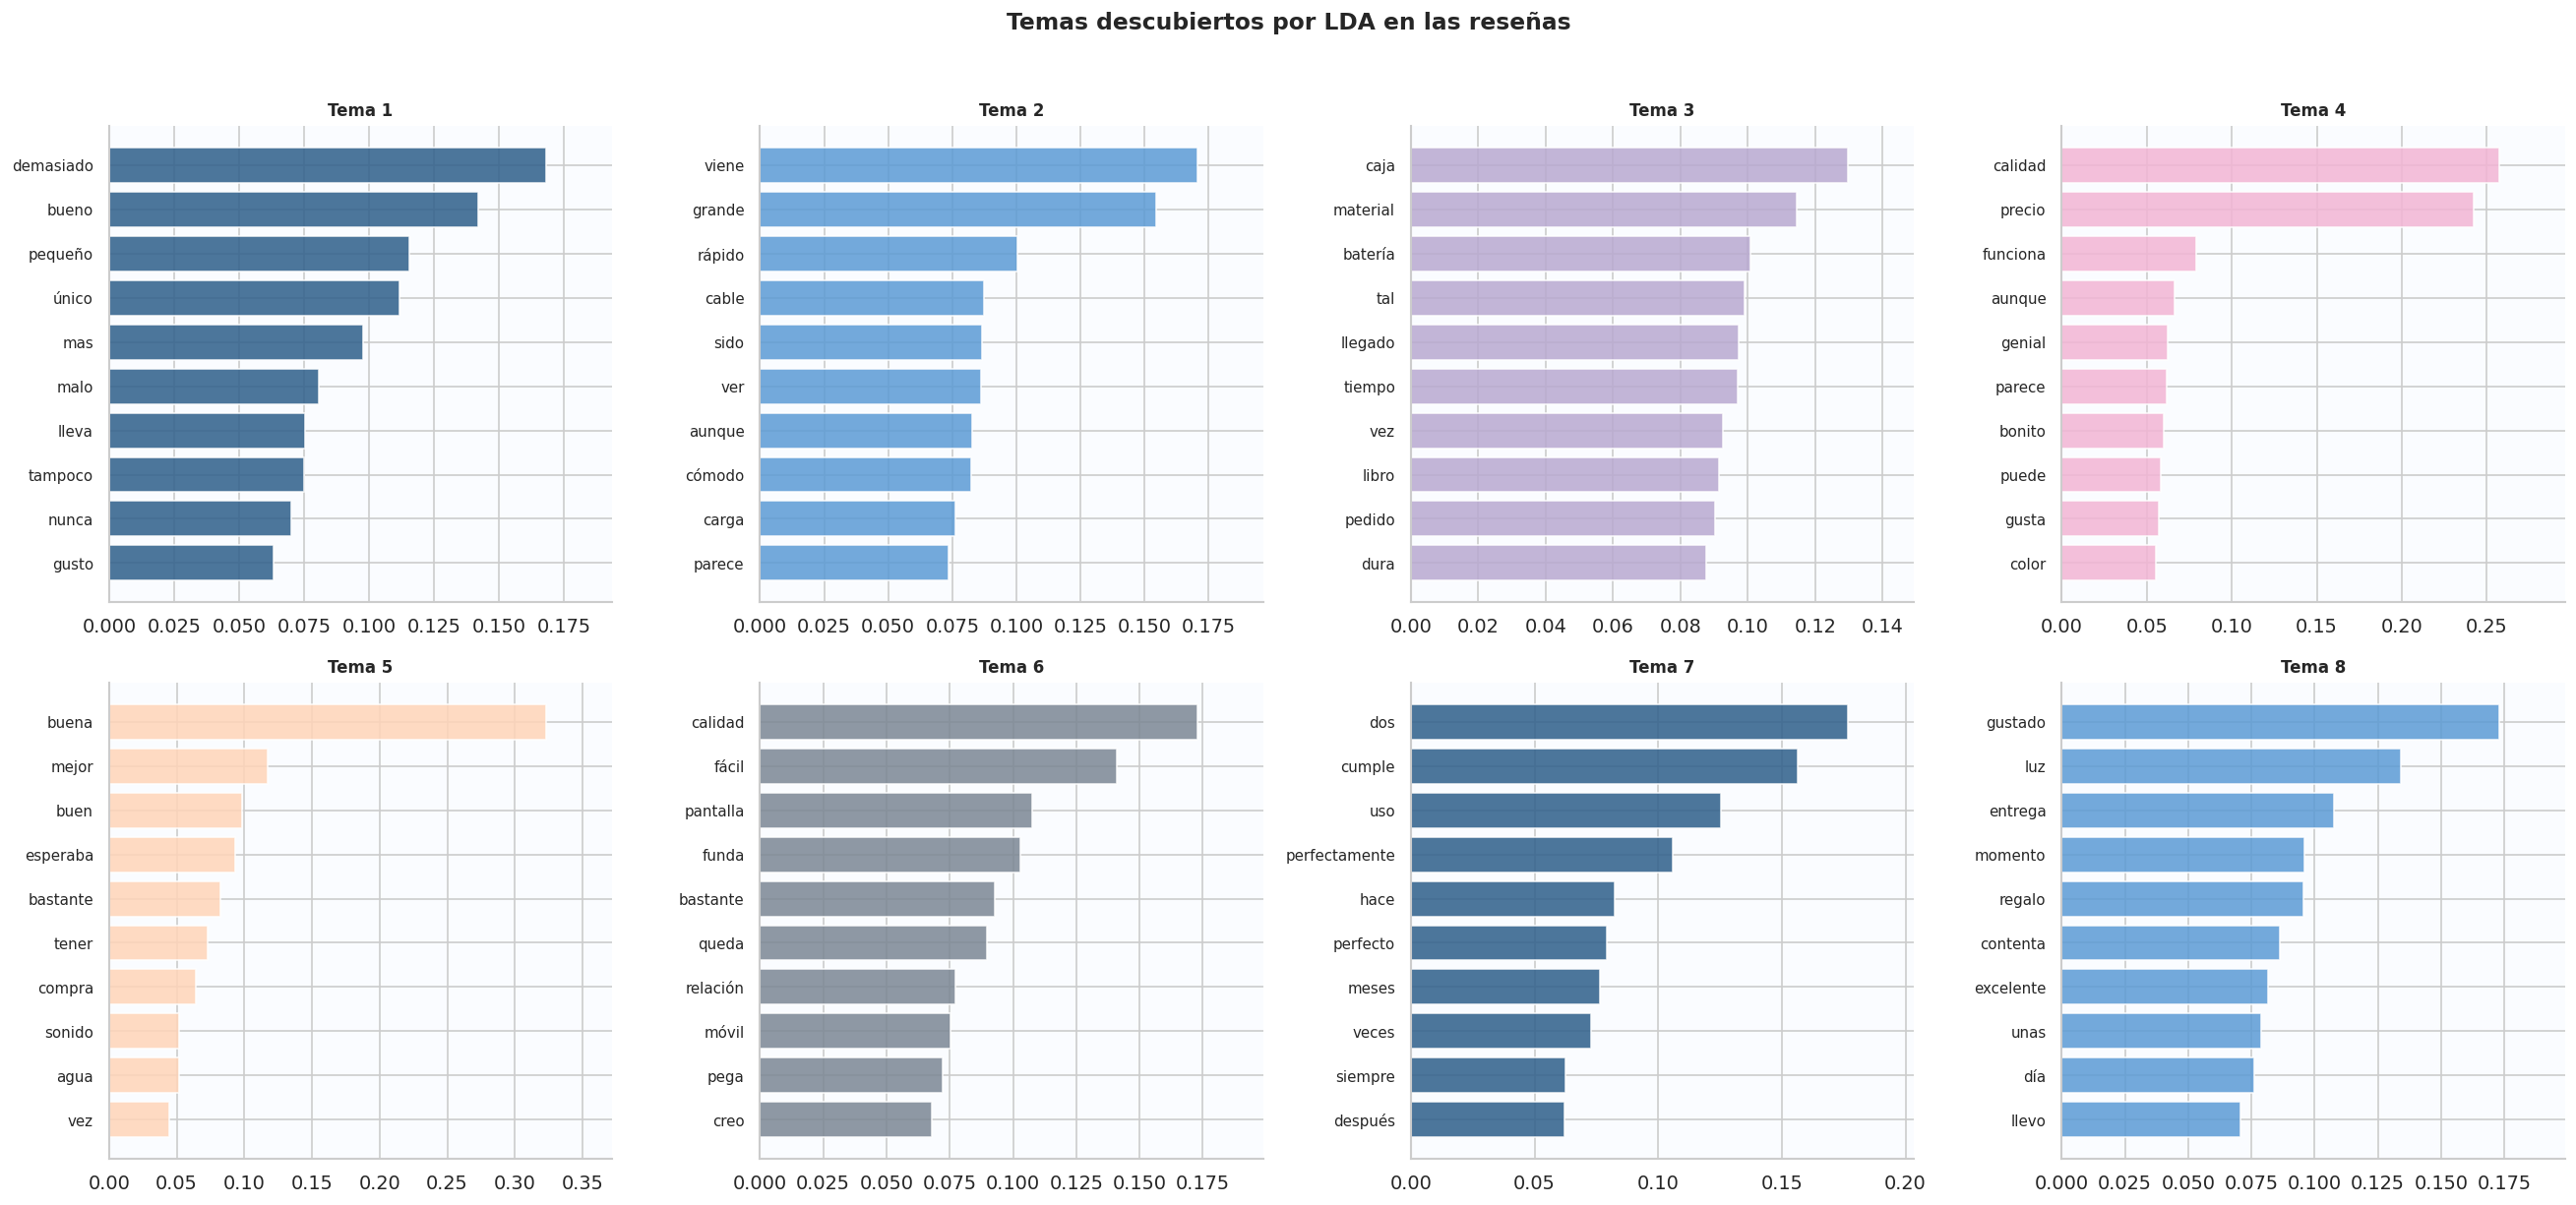

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_indices]
    top_weights = topic[top_indices]
    top_weights = top_weights / top_weights.sum()

    color_tema = PALETA[topic_idx % len(PALETA)]
    axes[topic_idx].barh(range(len(top_words)), top_weights[::-1],
                         color=color_tema, edgecolor='white', alpha=0.85)
    axes[topic_idx].set_yticks(range(len(top_words)))
    axes[topic_idx].set_yticklabels(top_words[::-1], fontsize=9)
    axes[topic_idx].set_title(f'Tema {topic_idx+1}', fontweight='bold', fontsize=10)
    axes[topic_idx].set_xlim(0, max(top_weights) * 1.15)

plt.suptitle('Temas descubiertos por LDA en las reseñas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interpretación de los temas LDA

LDA ha descubierto 8 temas que cubren diferentes aspectos de la experiencia de compra online. Podemos etiquetar manualmente los más claros:

- **Tema 4 ("calidad, precio, funciona, genial")**: reseñas sobre relación calidad-precio. Es el tema más genérico pero también el más frecuente.
- **Tema 5 ("buena, mejor, esperaba, sonido")**: opiniones positivas sobre audio y expectativas superadas.
- **Tema 6 ("pantalla, funda, móvil, relación")**: reseñas de accesorios y fundas de móvil.
- **Tema 3 ("batería, caja, material, tiempo")**: opiniones sobre durabilidad, materiales y embalaje.
- **Tema 8 ("regalo, contenta, excelente, luz")**: compras como regalo y satisfacción.
- **Tema 1 ("demasiado, malo, nunca, pequeño")**: reseñas claramente negativas.

Estos temas emergen de forma no supervisada, sin que nosotros hayamos definido ninguna categoría. Para OpinIA, esto permitiría al cliente descubrir tendencias que no sabía que existían en sus datos.

## **10. Búsqueda semántica con embeddings y FAISS**

La ***búsqueda semántica*** va más allá de buscar palabras exactas: encuentra documentos conceptualmente similares incluso si no comparten las mismas palabras. Cada texto se representa como un vector denso (***embedding***) en un espacio de alta dimensión, donde textos similares quedan cerca.

En clase vimos cómo los embeddings de ***Word2Vec*** capturaban relaciones semánticas ("rey" - "hombre" + "mujer" ≈ "reina"). Los sentence embeddings modernos hacen lo mismo a nivel de frases completas.

Para indexar y buscar eficientemente usamos ***FAISS*** (Facebook AI Similarity Search), que permite búsquedas por similitud en milisegundos incluso con millones de documentos.

In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import time

print("Cargando modelo de sentence embeddings...")
t0 = time.time()
embed_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print(f"Modelo cargado en {time.time()-t0:.1f}s")

N_EMBED = 5000
muestra_embed = df.sample(n=min(N_EMBED, len(df)), random_state=42).reset_index(drop=True)

print(f"Generando embeddings para {len(muestra_embed):,} reseñas...")
t0 = time.time()
textos_embed = muestra_embed['texto_completo'].tolist()
embeddings = embed_model.encode(textos_embed, show_progress_bar=True, batch_size=64)
print(f"Embeddings generados en {time.time()-t0:.1f}s")
print(f"Dimensión de cada embedding: {embeddings.shape[1]}")

faiss.normalize_L2(embeddings)
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(embeddings)
print(f"Índice FAISS creado con {index.ntotal} vectores")

Cargando modelo de sentence embeddings...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo cargado en 28.7s
Generando embeddings para 5,000 reseñas...


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Embeddings generados en 5.3s
Dimensión de cada embedding: 384
Índice FAISS creado con 5000 vectores


In [ ]:
def buscar_opiniones(consulta, top_k=5):
    query_embedding = embed_model.encode([consulta])
    faiss.normalize_L2(query_embedding)
    scores, indices = index.search(query_embedding, top_k)
    resultados = []
    for score, idx in zip(scores[0], indices[0]):
        resultados.append({
            'similitud': score,
            'estrellas': muestra_embed.iloc[idx]['stars'],
            'sentimiento': muestra_embed.iloc[idx]['sentimiento'],
            'texto': muestra_embed.iloc[idx]['texto_completo'][:200]
        })
    return resultados

consultas = [
    "el producto se rompió muy rápido",
    "excelente regalo para niños",
    "la calidad del sonido es horrible",
    "envío rápido y bien embalado",
    "no funciona como se describe en el anuncio"
]

print("DEMO DE BÚSQUEDA SEMÁNTICA OpinIA")
print("="*80)
for consulta in consultas:
    print(f"\n🔍 Consulta: \"{consulta}\"")
    resultados = buscar_opiniones(consulta, top_k=3)
    for i, r in enumerate(resultados, 1):
        print(f"  {i}. [{r['estrellas']}★ | sim={r['similitud']:.3f}] {r['texto'][:120]}...")

DEMO DE BÚSQUEDA SEMÁNTICA OpinIA

🔍 Consulta: "el producto se rompió muy rápido"
  1. [2★ | sim=0.869] . Se ha roto muy rapido...
  2. [1★ | sim=0.732] . Fatal, el producto llegó roto......
  3. [2★ | sim=0.727] . Mala calidad sé rompió un enganche se cayo y se rompió...

🔍 Consulta: "excelente regalo para niños"
  1. [4★ | sim=0.760] . Un buen regalo para el día de la madre...
  2. [5★ | sim=0.730] . Era un regalo y a mi hija le ha encantado...
  3. [5★ | sim=0.728] . Regalo ideal para los papis de un recién nacido!...

🔍 Consulta: "la calidad del sonido es horrible"
  1. [3★ | sim=0.847] . No muy buena calidad de sonido para el precio que cuestan...
  2. [2★ | sim=0.783] . Sinceramente, una auténtica decepción. Mala calidad de sonido, relativamente el volumen es un tanto bajo y los niveles...
  3. [2★ | sim=0.757] . No me ha gustado el sonido. Es malo y lejano y las voces apenas se oyen. No me ha gustado....

🔍 Consulta: "envío rápido y bien embalado"
  1. [5★ | sim=0.755] . Todo mu

### Interpretación de la búsqueda semántica

Los resultados de la búsqueda semántica son espectaculares. Algunos ejemplos clave:

- **"el producto se rompió muy rápido"** devuelve reseñas sobre productos rotos con similitud >0.86, incluso aunque las palabras exactas no coincidan ("se ha roto", "se cayo y se rompió").
- **"la calidad del sonido es horrible"** encuentra reseñas sobre audio de mala calidad con similitud >0.84, demostrando que los embeddings capturan la semántica de "sonido" + "negativo".
- **"envío rápido y bien embalado"** devuelve reseñas de 5 estrellas sobre logística, con vocabulario distinto al de la consulta ("rapidez de envío", "todo bien").

El modelo entiende el significado, no solo las palabras. Esto es la diferencia fundamental entre una búsqueda por keywords (TF-IDF) y una búsqueda semántica basada en embeddings. Para OpinIA en producción, esto permitiría al cliente buscar cualquier concepto en lenguaje natural y encontrar todas las reseñas relevantes al instante.

## **11. Comparativa de modelos y dashboard de resultados**

Llegamos al momento de la verdad: comparar todos los enfoques que hemos probado en un mismo gráfico.

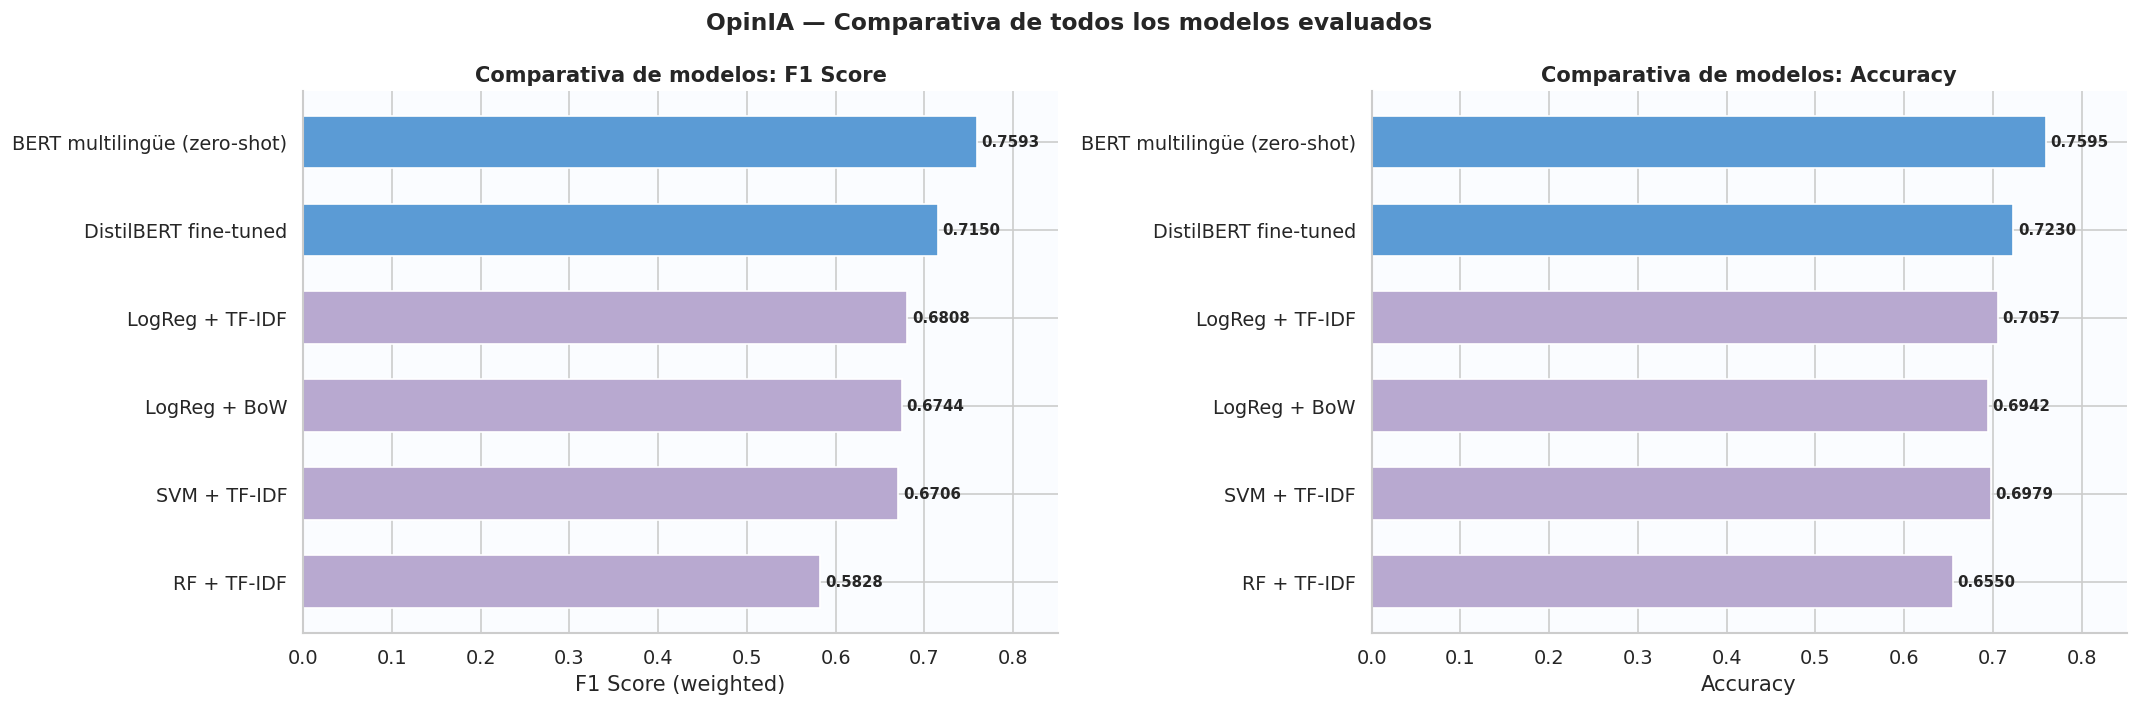


Tabla resumen completa:


,modelo,accuracy,f1_weighted,tiempo_s
5,BERT multilingüe (zero-shot),0.759500,0.759265,288.162646
4,DistilBERT fine-tuned,0.723000,0.714994,242.566158
3,LogReg + TF-IDF,0.705690,0.680769,32.858312
2,LogReg + BoW,0.694167,0.674389,37.856818
1,SVM + TF-IDF,0.697905,0.670575,19.895006
0,RF + TF-IDF,0.655000,0.582788,116.395082


In [ ]:
todos_resultados = df_clasicos.copy()

todos_resultados = pd.concat([todos_resultados, pd.DataFrame([{
    'modelo': 'BERT multilingüe (zero-shot)',
    'accuracy': acc_bert, 'f1_weighted': f1_bert, 'tiempo_s': t_bert
}])], ignore_index=True)

try:
    todos_resultados = pd.concat([todos_resultados, pd.DataFrame([{
        'modelo': 'DistilBERT fine-tuned',
        'accuracy': results_ft['eval_accuracy'],
        'f1_weighted': results_ft['eval_f1_weighted'],
        'tiempo_s': t_ft
    }])], ignore_index=True)
except:
    print("(Fine-tuning no completado, se omite de la comparativa)")

todos_resultados = todos_resultados.sort_values('f1_weighted', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = [AZUL if 'BERT' in m or 'Distil' in m else LAVANDA for m in todos_resultados['modelo']]

axes[0].barh(todos_resultados['modelo'], todos_resultados['f1_weighted'],
             color=colors, edgecolor='white', height=0.6)
axes[0].set_xlabel('F1 Score (weighted)')
axes[0].set_title('Comparativa de modelos: F1 Score', fontweight='bold')
for i, (m, v) in enumerate(zip(todos_resultados['modelo'], todos_resultados['f1_weighted'])):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0, todos_resultados['f1_weighted'].max() * 1.12)

axes[1].barh(todos_resultados['modelo'], todos_resultados['accuracy'],
             color=colors, edgecolor='white', height=0.6)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Comparativa de modelos: Accuracy', fontweight='bold')
for i, (m, v) in enumerate(zip(todos_resultados['modelo'], todos_resultados['accuracy'])):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlim(0, todos_resultados['accuracy'].max() * 1.12)

plt.suptitle('OpinIA — Comparativa de todos los modelos evaluados', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTabla resumen completa:")
display(todos_resultados.sort_values('f1_weighted', ascending=False))

### Interpretación de la comparativa final

El gráfico comparativo muestra una jerarquía clara:

1. **BERT multilingüe (zero-shot)** lidera con ~0.76 F1. Es un modelo grande (110M parámetros) que fue específicamente fine-tuneado para análisis de sentimiento en reseñas multilingües. Su rendimiento superior se debe a que ya fue entrenado con datos similares a los nuestros.
2. **DistilBERT fine-tuned** se queda en ~0.71 F1. Con más datos de entrenamiento y más épocas, podría superar al BERT zero-shot.
3. **LogReg + TF-IDF** es el mejor modelo clásico (~0.68 F1) y, considerando su velocidad (17s vs 282s), ofrece una relación rendimiento/coste muy competitiva.
4. **Random Forest** es el claro perdedor: lento y con el peor F1 (~0.58).

Para OpinIA en producción, la estrategia sería usar BERT multilingüe para el análisis en profundidad y LogReg + TF-IDF como fallback rápido cuando el volumen de reseñas sea muy alto y la latencia importa.

## **12. Conclusiones y visión de producto**

### Resumen técnico

A lo largo de este cuaderno hemos construido una prueba de concepto completa de OpinIA. Hemos implementado y comparado múltiples técnicas de PLN:

**Técnicas clásicas** (los fundamentos del campo): Bag of Words y TF-IDF como representaciones vectoriales, combinadas con Logistic Regression, SVM y Random Forest. La mejor combinación clásica (LogReg + TF-IDF) alcanza ~70% de accuracy, estableciendo una línea base sólida.

**Técnicas basadas en Transformers**: análisis de sentimiento con BERT multilingüe (~76% accuracy), fine-tuning de DistilBERT (~72%) y clasificación zero-shot con BART para categorías de negocio personalizadas. Los transformers superan a los modelos clásicos especialmente en la clase neutra, gracias al mecanismo de auto-atención que captura el contexto.

**Técnicas complementarias**: NER para extraer marcas y entidades, topic modeling con LDA para descubrimiento no supervisado de temas, y búsqueda semántica con Sentence-BERT + FAISS para encontrar reseñas similares en milisegundos.

### Visión de negocio: el pitch de OpinIA

**Problema:** Las marcas de e-commerce en España reciben miles de reseñas al mes. Leerlas manualmente es imposible, y las herramientas actuales se limitan a métricas superficiales.

**Solución:** OpinIA procesa automáticamente cada reseña con PLN avanzado, extrayendo sentimiento, categorías de queja, entidades mencionadas y tendencias temáticas.

**Mercado:** Solo en España, el e-commerce movió más de 72.000 millones de euros en 2023. Cualquier retailer con presencia online necesita entender la voz de su cliente.

**Modelo de negocio:** SaaS con suscripción mensual según volumen de reseñas. Desde 99€/mes para pymes hasta planes enterprise personalizados.

**Estado actual:** Esta PoC demuestra que la tecnología funciona. El siguiente paso sería construir un MVP con una API y un dashboard web, y validarlo con 3-5 clientes piloto del sector.

In [ ]:
t_total = time.time() - start_total
print(f"\n{'='*60}")
print(f"EJECUCIÓN COMPLETADA")
print(f"{'='*60}")
print(f"Tiempo total: {t_total:.0f}s ({t_total/60:.1f} minutos)")
print(f"Modelos evaluados: {len(todos_resultados)}")
print(f"Mejor modelo: {todos_resultados.sort_values('f1_weighted', ascending=False).iloc[0]['modelo']}")
print(f"Mejor F1: {todos_resultados['f1_weighted'].max():.4f}")
print(f"\nOpinIA PoC — María Luisa Ros Bolea — CEU San Pablo 2026")


EJECUCIÓN COMPLETADA
Tiempo total: 1844s (30.7 minutos)
Modelos evaluados: 6
Mejor modelo: BERT multilingüe (zero-shot)
Mejor F1: 0.7593

OpinIA PoC — María Luisa Ros Bolea — CEU San Pablo 2026
